Vasicek MC P(0,2) ≈ 0.950991 (stderr 2.483e-18)
Vasicek analytic P(0,2) = 0.958281
CIR MC P(0,2) ≈ 0.929371 (stderr 0.000e+00)


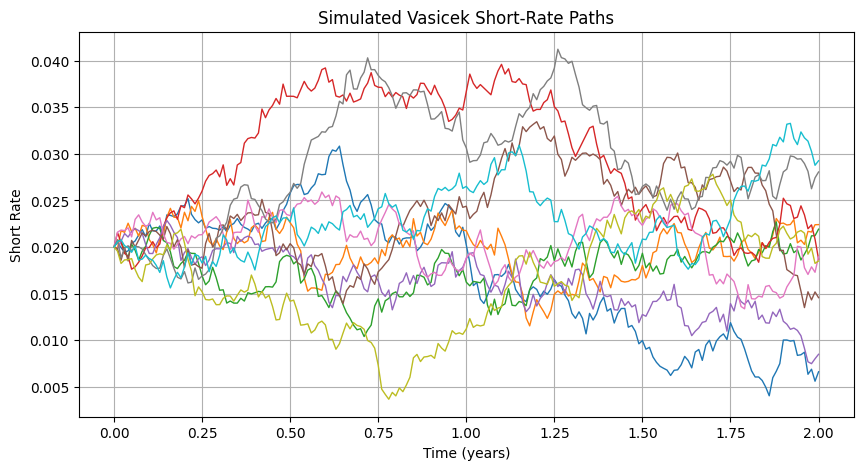

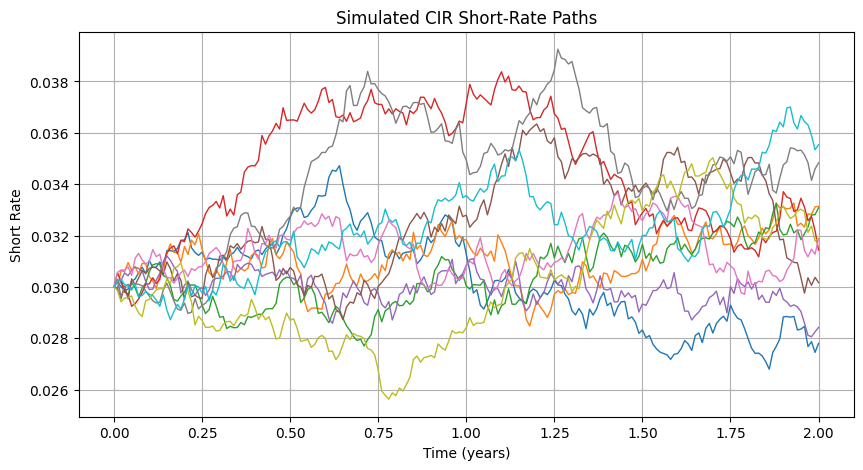

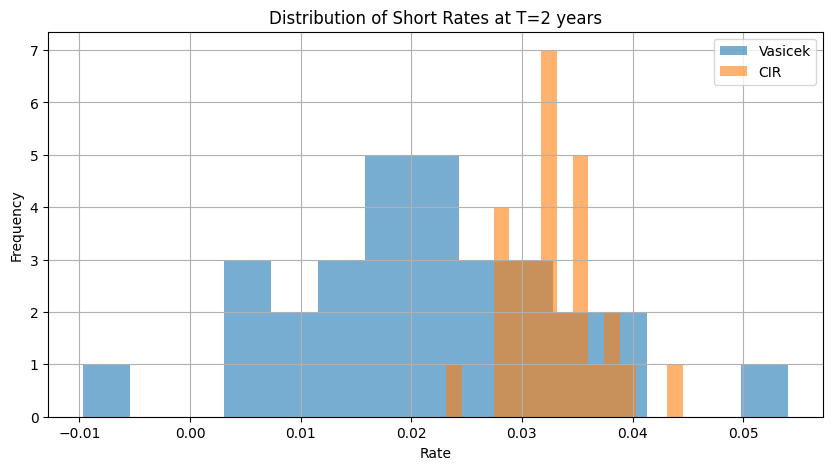

Demo complete with plots.


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from src.srtoolkit.models.vasicek import Vasicek
from src.srtoolkit.models.cir import CIR
from src.srtoolkit.sim.monte_carlo import monte_carlo_price_zero_coupon


def simulate_paths(model, T, n_steps, n_paths, seed=42):
    """Generic path simulator for Vasicek or CIR models (for plotting)."""
    np.random.seed(seed)
    dt = T / n_steps
    rates = np.zeros((n_paths, n_steps + 1))
    rates[:, 0] = model.r0

    kappa = model.params["kappa"]
    theta = model.params["theta"]
    sigma = model.params["sigma"]

    for t in range(1, n_steps + 1):
        if isinstance(model, Vasicek):
            dr = kappa * (theta - rates[:, t-1]) * dt + sigma * np.sqrt(dt) * np.random.randn(n_paths)
            rates[:, t] = rates[:, t-1] + dr
        else:  # CIR
            dr = kappa * (theta - rates[:, t-1]) * dt + sigma * np.sqrt(np.maximum(rates[:, t-1], 0) * dt) * np.random.randn(n_paths)
            rates[:, t] = np.maximum(rates[:, t-1] + dr, 0)
    return rates


def main():
    # Vasicek setup
    vas_params = {"kappa": 0.15, "theta": 0.03, "sigma": 0.01}
    v = Vasicek.from_dict(r0=0.02, params=vas_params)
    price_mc, stderr = monte_carlo_price_zero_coupon(v, n_paths=2000, T=2.0, n_steps=200, n_workers=6)
    print(f"Vasicek MC P(0,2) ≈ {price_mc:.6f} (stderr {stderr:.3e})")
    analytic = v.zero_coupon_bond_price(0.0, 2.0, v.r0)
    print(f"Vasicek analytic P(0,2) = {analytic:.6f}")

    # CIR setup
    cir_params = {"kappa": 0.2, "theta": 0.04, "sigma": 0.02}
    c = CIR.from_dict(r0=0.03, params=cir_params)
    price_mc_c, stderr_c = monte_carlo_price_zero_coupon(c, n_paths=2000, T=2.0, n_steps=200)
    print(f"CIR MC P(0,2) ≈ {price_mc_c:.6f} (stderr {stderr_c:.3e})")

    # ====== PLOTTING ======
    T, n_steps, n_paths = 2.0, 200, 30
    time_grid = np.linspace(0, T, n_steps + 1)

    # Simulate sample paths
    vas_paths = simulate_paths(v, T, n_steps, n_paths)
    cir_paths = simulate_paths(c, T, n_steps, n_paths)

    # Plot Vasicek paths
    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.plot(time_grid, vas_paths[i], lw=1)
    plt.title("Simulated Vasicek Short-Rate Paths")
    plt.xlabel("Time (years)")
    plt.ylabel("Short Rate")
    plt.grid(True)
    plt.show()

    # Plot CIR paths
    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.plot(time_grid, cir_paths[i], lw=1)
    plt.title("Simulated CIR Short-Rate Paths")
    plt.xlabel("Time (years)")
    plt.ylabel("Short Rate")
    plt.grid(True)
    plt.show()

    # Distribution at maturity
    plt.figure(figsize=(10, 5))
    plt.hist(vas_paths[:, -1], bins=15, alpha=0.6, label="Vasicek")
    plt.hist(cir_paths[:, -1], bins=15, alpha=0.6, label="CIR")
    plt.title("Distribution of Short Rates at T=2 years")
    plt.xlabel("Rate")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Demo complete with plots.")


if __name__ == "__main__":
    main()
